In [1]:
import os, glob, random, math, pickle
import numpy as np 
import h5py 
import matplotlib.pyplot as plt 
from pathlib import Path
from numpy import fft 
import torch 
import torch.nn as nn 
import torch.nn.functional as F 
from torch.utils.data import Dataset, DataLoader 
os.environ['HDF5_USE_FILE_LOCKING'] = 'FALSE'

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print(DEVICE, torch.cuda.get_device_name(DEVICE) if DEVICE.type=="cuda" else "")



cuda:0 NVIDIA RTX A6000


In [2]:
ROOT= Path("..").resolve()
DATA= ROOT/"data"

TRAIN_DIR= DATA/"multicoil_train"
VAL_DIR= DATA/"multicoil_val"
TEST_DIR=DATA/"multicoil_test"
CACHE_DIR=DATA/"cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

train_files=sorted(TRAIN_DIR.glob("file_brain_*.h5"))
val_files=sorted(VAL_DIR.glob("file_brain_*.h5"))
test_files=sorted(TEST_DIR.glob("file_brain_*.h5"))

print(len(train_files),len(val_files),len(test_files))

455 460 186


UTILS

In [ ]:
import sys
sys.path.insert(0, str(ROOT / "src"))
import importlib
import utils
importlib.reload(utils)
from pygrappa import grappa, mdgrappa
from utils import (
    estimate_mdgrappa_kernel,
    calculate_mask,
    comp_sub_kspace,
    comp_img,
    apply_kernel_weight,
)

TARGET_COILS=16
ACCEL=4
CENTER_FRACTION=0.08
KERNEL_SIZE=(5,5)
CROP_SIZE=(32,640,320)
MAX_FILES=None
SEED=42

#keeping only the files which have 16 coil data
train_files_fixed=[]
for p in train_files:
    with h5py.File(p,"r") as f:
        if f["kspace"].shape[1]==TARGET_COILS:
            train_files_fixed.append(p)
files_to_use = train_files_fixed if MAX_FILES is None else train_files_fixed[:MAX_FILES]
print("using", len(files_to_use), "of", len(train_files_fixed), "files")
X_train, Y_train, grappa_wt, grappa_p = [], [], [], []
for fi, mri_f in enumerate(files_to_use):
    filename=mri_f.stem
    with h5py.File(mri_f,"r") as f:
        k = f["kspace"][()]
        nSL,nCh,nFE,nPE=k.shape
        np.random.seed(SEED +fi)
        mask2d=calculate_mask(nFE,nPE,CENTER_FRACTION,ACCEL)
        subsampled_k=k*mask2d[None,None,:,:]
    #here we are developing a mask to make the fully sampled space unedrsampled. Our ACS is 0.08 meaning keeping 8% of the original data(the centre location). Here R=4.

        for sl in range(nSL):
            wt,ps=estimate_mdgrappa_kernel( #ps is position of the missing lines
                kspace=subsampled_k[sl],
                calib=None, #None means it will automatically look for ACS
                kernel_size=KERNEL_SIZE,
                coil_axis=0,
            )

            ref_img=np.zeros((nCh,nFE,nPE),dtype=np.float32) #per slice reference coil images, no *2 because this will not be fed to a CNN
            sub_kspace=np.zeros((nCh*2,nFE,nPE),dtype=np.float32) #per slice undersampled image that will be fed to a CNN. Now the CNN can not handle the complex input so we do 2*ch
            for iCh in range(nCh):
                ref_img[iCh] = np.abs(
                    fft.fftshift(fft.ifft2(k[sl, iCh]))
                    )
                sub_kspace[iCh] = subsampled_k[sl, iCh].real
                sub_kspace[iCh + nCh] = subsampled_k[sl, iCh].imag #imaginary channels are after half. Example 2 coils 4 channels. 3rd and 4th are imag so if we do i+n (0+2) it will give imag.

            X_train.append(comp_sub_kspace(sub_kspace,CROP_SIZE))
            Y_train.append(comp_img(ref_img, (CROP_SIZE[0] // 2, CROP_SIZE[1], CROP_SIZE[2])))
            grappa_wt.append(wt)
            grappa_p.append(ps)
    print(fi + 1, filename, "slices:", nSL, "coils:", nCh, "k-space:", (nFE, nPE))
print("samples:", len(X_train))
print("example X shape:", np.array(X_train[0]).shape)
print("example Y shape:", np.array(Y_train[0]).shape)
print("grappa weights:", len(grappa_wt))

150 train files


/home/ishita/my_projects/brain-mri-recon/src/utils.py:97: RuntimeWarning: invalid value encountered in scalar divide
  Ws = train_kernels(kspace.astype(np.complex128), nc, A.astype(np.complex128), P,


1 file_brain_AXFLAIR_200_6002469 slices: 16 coils: 16 k-space: (640, 320)
2 file_brain_AXFLAIR_200_6002512 slices: 16 coils: 16 k-space: (640, 320)
3 file_brain_AXFLAIR_200_6002629 slices: 16 coils: 16 k-space: (640, 320)
4 file_brain_AXFLAIR_200_6002641 slices: 16 coils: 16 k-space: (640, 320)
5 file_brain_AXFLAIR_201_6002914 slices: 16 coils: 16 k-space: (640, 274)
6 file_brain_AXFLAIR_201_6002934 slices: 16 coils: 16 k-space: (640, 320)
7 file_brain_AXFLAIR_201_6002940 slices: 16 coils: 16 k-space: (640, 320)
8 file_brain_AXFLAIR_201_6002960 slices: 16 coils: 16 k-space: (640, 320)
9 file_brain_AXFLAIR_201_6002964 slices: 16 coils: 16 k-space: (640, 320)
10 file_brain_AXFLAIR_202_6000421 slices: 16 coils: 16 k-space: (640, 312)
11 file_brain_AXFLAIR_202_6000508 slices: 16 coils: 16 k-space: (640, 264)
12 file_brain_AXFLAIR_202_6000531 slices: 16 coils: 16 k-space: (640, 264)
13 file_brain_AXFLAIR_202_6000539 slices: 16 coils: 16 k-space: (640, 264)
14 file_brain_AXFLAIR_209_6001386 

ValueError: could not broadcast input array from shape (32,768,396) into shape (32,640,320)

Saving the prepared data and the weights

In [ ]:
X_train = np.array(X_train, dtype=np.float32)
Y_train = np.array(Y_train, dtype=np.float32)

np.save(CACHE_DIR / "X_train.npy", X_train)
np.save(CACHE_DIR / "Y_train.npy", Y_train)

with open(CACHE_DIR / "grappa_wt.pkl", "wb") as f:
    pickle.dump(grappa_wt, f, protocol=pickle.HIGHEST_PROTOCOL)
with open(CACHE_DIR / "grappa_p.pkl", "wb") as f:
    pickle.dump(grappa_p, f, protocol=pickle.HIGHEST_PROTOCOL)

print("saved to", CACHE_DIR)
print(X_train.shape, Y_train.shape, len(grappa_wt))

saved to /home/ishita/my_projects/brain-mri-recon/data/cache
(16, 32, 640, 320) (16, 16, 640, 320) 16


RSS Saving

In [ ]:
Y_rss=np.sqrt(np.sum(np.square(Y_train),axis=1)).astype(np.float32) #RSS reference
Y_train = np.asarray(Y_train) 
X_train = np.asarray(X_train) 
print(X_train.shape,Y_rss.shape)

(16, 32, 640, 320) (16, 640, 320)


Normalization

In [ ]:
N,C= X_train.shape[0],X_train.shape[1]

for n in range(N):
    for c in range(C):
        ch=X_train[n,c]
        X_train[n,c]=ch/((ch.max()-ch.min())+1e-10)
    Y_rss[n] = Y_rss[n]/ ((Y_rss[n].max() - Y_rss[n].min()) + 1e-10)

Training and Validation Split

In [ ]:
n_test=int(X_train.shape[0]*0.1)
n_tr   = X_train.shape[0] - n_test

class GrappaDataset(Dataset):
    def __init__(self,X,Y,idx):
        self.X,self.Y,self.idx,=X,Y,idx
    def __len__(self):return len(self.idx)
    def __getitem__(self, i):
        j = self.idx[i]
        return (
            torch.from_numpy(self.X[j]).float(),
            torch.tensor(j, dtype=torch.long),
            torch.from_numpy(self.Y[j]).float(),
        )

train_idx = np.arange(0, n_tr)
test_idx  = np.arange(n_tr, X_train.shape[0])

train_ds = GrappaDataset(X_train, Y_rss, train_idx)
test_ds  = GrappaDataset(X_train, Y_rss, test_idx)
train_dl = DataLoader(train_ds, batch_size=2, shuffle=False, num_workers=4)
test_dl  = DataLoader(test_ds,  batch_size=2, shuffle=False, num_workers=4)          

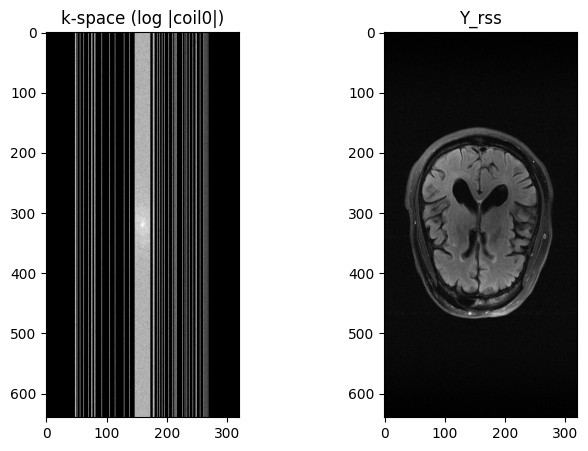

In [ ]:
idx = 0
nCh = 16
ks = X_train[idx, :nCh] + 1j * X_train[idx, nCh:]   # (coils, H, W)
mag = np.abs(ks[0])                                   # one coil

fig, ax = plt.subplots(1, 2, figsize=(8, 5))
ax[0].imshow(np.log(mag + 1e-8), cmap="gray")
ax[0].set_title("k-space (log |coil0|)")
ax[1].imshow(Y_rss[idx], cmap="gray")
ax[1].set_title("Y_rss")
plt.show()

In [ ]:
print("train_dl" in dir(), "test_dl" in dir())  
print(X_train.shape, Y_rss.shape, len(grappa_wt))

True True
(16, 32, 640, 320) (16, 640, 320) 16


In [ ]:
import fastmri
from fastmri.models import Unet

n_coils=16
n_ch=2*n_coils 

def ch_to_complex_last(x):
    """(B,2C,H,W)-> (B,C,H,W,2)""" 
    c=x.shape[1]//2
    return torch.stack((x[:,:c],x[:,c:]),dim=-1)

def complex_last_to_ch(x):
    """(B, C, H, W, 2) -> (B, 2C, H, W)"""
    return torch.cat((x[..., 0], x[..., 1]), dim=1)

def data_consistency(k_meas_ch, k_pred_ch):
    """Keep acquired samples from k_meas, fill holes from k_pred. (B, 2C, H, W)"""
    c = k_meas_ch.shape[1] // 2
    mag2 = k_meas_ch[:, :c] ** 2 + k_meas_ch[:, c:] ** 2
    mask_c = (mag2 > 0).to(k_meas_ch.dtype)
    mask = torch.cat([mask_c, mask_c], dim=1)
    return mask * k_meas_ch + (1.0 - mask) * k_pred_ch

def apply_grappa_batch(k_ch, idxs):
    device = k_ch.device
    k_np = k_ch.detach().cpu().numpy()
    outs = []
    for b in range(k_np.shape[0]):
        i = int(idxs[b].item())
        kc = k_np[b, :n_coils] + 1j * k_np[b, n_coils:]
        filled = apply_kernel_weight(
            kspace=kc,
            kernel_size=KERNEL_SIZE,
            coil_axis=0,
            weights=grappa_wt[i],
            P=grappa_p[i],
        )
        outs.append(np.concatenate([filled.real, filled.imag], axis=0))
    return torch.from_numpy(np.stack(outs).astype(np.float32)).to(device)


class GrappaNet(nn.Module):
    """CNN cascade + classical GRAPPA, using fastmri Unet + FFT/RSS."""
    def __init__(self, chans=32, num_pool_layers=4, drop_prob=0.05):
        super().__init__()
        self.unet_k1 = Unet(n_ch, n_ch, chans, num_pool_layers, drop_prob)
        self.unet_i1 = Unet(n_ch, n_ch, chans, num_pool_layers, drop_prob)
        self.unet_k2 = Unet(n_ch, n_ch, chans, num_pool_layers, drop_prob)
        self.unet_i2 = Unet(n_ch, n_ch, chans, num_pool_layers, drop_prob)
    def cascade(self, x_in, k_meas, unet_k, unet_i):
        # k-space UNet + DC
        k = data_consistency(k_meas, unet_k(x_in))
        # image-domain UNet
        img = complex_last_to_ch(fastmri.ifft2c(ch_to_complex_last(k)))
        img = unet_i(img)
        # back to k-space + DC
        k = data_consistency(k_meas, complex_last_to_ch(fastmri.fft2c(ch_to_complex_last(img))))
        return k
    def forward(self, k_meas, grappa_idx):
        # pass 1
        k = self.cascade(k_meas, k_meas, self.unet_k1, self.unet_i1)
        # classical GRAPPA (no autograd through pygrappa)
        with torch.no_grad():
            k_g = apply_grappa_batch(k, grappa_idx)
        # pass 2
        k = self.cascade(k_g, k_meas, self.unet_k2, self.unet_i2)
        # RSS image
        return fastmri.rss_complex(fastmri.ifft2c(ch_to_complex_last(k)), dim=1)


In [ ]:
model = GrappaNet().to(DEVICE)
print(f"params: {sum(p.numel() for p in model.parameters())/1e6:.2f}M")
# smoke test
xb, ib, yb = next(iter(train_dl))
xb, ib, yb = xb.to(DEVICE), ib.to(DEVICE), yb.to(DEVICE)
with torch.no_grad():
    pred = model(xb, ib)
print("pred", pred.shape, "target", yb.shape)

params: 31.06M
pred torch.Size([2, 640, 320]) target torch.Size([2, 640, 320])


In [ ]:
from fastmri import SSIMLoss

loss_ssim = SSIMLoss().to(DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=3e-4)
lam_l1 = 1e-3
epochs = 5
ckpt_dir = ROOT / "checkpoints"
ckpt_dir.mkdir(exist_ok=True)

# fixed sample for inference-over-time plots
viz_dl = test_dl if len(test_ds) else train_dl
viz_x, viz_i, viz_y = next(iter(viz_dl))
viz_x = viz_x[:1].float().to(DEVICE)
viz_i = viz_i[:1].to(DEVICE)
viz_y = viz_y[:1].float().to(DEVICE)

history = {"train": []}
epoch_preds = []

for epoch in range(epochs):
    model.train()
    total = 0.0
    for xb, ib, yb in train_dl:
        xb = xb.float().to(DEVICE)
        yb = yb.float().to(DEVICE)
        ib = ib.to(DEVICE)

        pred = model(xb, ib)
        ssim = loss_ssim(pred[:, None], yb[:, None], data_range=yb.max().expand(len(yb)))
        l1 = F.l1_loss(pred, yb)
        loss = ssim + lam_l1 * l1

        opt.zero_grad()
        loss.backward()
        opt.step()
        total += loss.item()

    model.eval()
    with torch.no_grad():
        epoch_preds.append(model(viz_x, viz_i)[0].detach().cpu().numpy())

    avg = total / len(train_dl)
    history["train"].append(avg)
    print(f"epoch {epoch+1}/{epochs}  loss={avg:.4f}")

torch.save(
    {
        "model": model.state_dict(),
        "history": history,
        "epoch_preds": epoch_preds,
        "viz_target": viz_y[0].detach().cpu().numpy(),
    },
    ckpt_dir / "grappanet_smoke.pt",
)
print("saved", ckpt_dir / "grappanet_smoke.pt")


## Loss + inference over time




In [ ]:
# loss curve
epochs_x = np.arange(1, len(history["train"]) + 1)
plt.figure(figsize=(5, 3.5))
plt.plot(epochs_x, history["train"], marker="o")
plt.xlabel("epoch")
plt.ylabel("loss (1-SSIM + λ L1)")
plt.title("Training loss over time")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# inference over epochs on fixed sample
target = viz_y[0].detach().cpu().numpy()
n = len(epoch_preds)
pick = sorted(set([0, n // 2, n - 1]))
cols = 1 + len(pick) + 1
fig, axes = plt.subplots(1, cols, figsize=(3.2 * cols, 3.5))

axes[0].imshow(target, cmap="gray")
axes[0].set_title("target")
for j, ep in enumerate(pick):
    axes[j + 1].imshow(epoch_preds[ep], cmap="gray")
    axes[j + 1].set_title(f"pred ep {ep + 1}")
axes[-1].imshow(np.abs(epoch_preds[-1] - target), cmap="magma")
axes[-1].set_title("|error| last")
for a in axes:
    a.axis("off")
plt.suptitle("Inference over training", y=1.02)
plt.tight_layout()
plt.show()

# MAE over epochs
mae = [np.mean(np.abs(p - target)) for p in epoch_preds]
plt.figure(figsize=(5, 3))
plt.plot(epochs_x, mae, marker="o")
plt.xlabel("epoch")
plt.ylabel("MAE (fixed sample)")
plt.title("Reconstruction error over time")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
